In [1]:
import os
import torch
import torch.nn as nn
import torchvision
from torchinfo import summary
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1, stride=1),    # (1, 28, 28) -> (32, 28, 28)
            nn.MaxPool2d(kernel_size=2, stride=2),    # (32, 28, 28) -> (32, 14, 14)
            nn.ReLU(),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1, stride=1),    # (32, 14, 14) -> (64, 14, 14)
            nn.MaxPool2d(kernel_size=2, stride=2),    # (64, 14, 14) -> (64, 7, 7)
            nn.ReLU(),
        )

        self.mu_layer = nn.Linear(64*7*7, latent_dim)    # (1, 64*7*7) -> (1, latent_dim)
        self.logvar_layer = nn.Linear(64*7*7, latent_dim)    # (1, 64*7*7) -> (1, latent_dim)
    
    def forward(self, img):
        x = self.conv_layers(img)
        x = x.view(x.size(0), -1)    # (64, 7, 7) -> (1, 64*7*7)

        mu = self.mu_layer(x)
        logvar = self.logvar_layer(x)

        return mu, logvar

In [3]:
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.fcnn_layer = nn.Linear(latent_dim, 64*7*7)    # (1, latent_dim) -> (1, 64*7*7)

        self.conv_layers = nn.Sequential(
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=4, padding=1, stride=2),    # (64, 7, 7) -> (32, 14, 14)
            nn.ReLU(),

            nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=4, padding=1, stride=2),    # (32, 14, 14) -> (3, 28, 28)
            nn.Sigmoid(),
        )
    
    def forward(self, latent):
        x = self.fcnn_layer(latent)
        x = x.view(x.size(0), 64, 7, 7)    # (1, 64*7*7) -> (64, 7, 7)

        img = self.conv_layers(x)
        return img

In [4]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
    
    def forward(self, img):
        mu, logvar = self.encoder(img)

        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std

        out = self.decoder(z)
        return out, mu, logvar

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device {device}")

latent_dim = 64
vae = VAE(latent_dim)
vae = vae.to(device)
vae_model_path = "task1_results/best_model.pt"
vae.load_state_dict(torch.load(vae_model_path))

Using device cuda


<All keys matched successfully>

In [6]:
train_data_pt = torch.load('data/train_mnist.pt')
images = train_data_pt['images']  
labels = train_data_pt['labels']

train_data = TensorDataset(images, labels)

test_data_pt = torch.load('data/test_mnist.pt')
images = test_data_pt['images']  
labels = test_data_pt['labels']

test_data = TensorDataset(images, labels)

In [7]:
batch_size = 12    # We specifically choose a batch size of 12 since we know that a single image has 11 rotated versions
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=4)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=4)

In [8]:
if not (os.path.exists("data/train_rotated_latents.pt") and os.path.exists("data/test_rotated_latents.pt")):
    train_img_latents = []
    train_img_rotated_latents = []
    test_img_latents = []
    test_img_rotated_latents = []

    vae.eval()
    with torch.no_grad():
        for img, label in tqdm(train_dataloader, desc="Creating Train Dataset"):
            img = img.to(device)
            label = label.to(device)
            
            mu, logvar = vae.encoder(img)

            for i in range(11):
                train_img_latents.append(mu[i].detach().cpu())
                train_img_rotated_latents.append(mu[i+1].detach().cpu())
            
            train_img_latents.append(mu[-1].detach().cpu())
            train_img_rotated_latents.append(mu[0].detach().cpu())

    with torch.no_grad():
        for img, label in tqdm(test_dataloader, desc="Creating Test Dataset"):
            img = img.to(device)
            label = label.to(device)
            
            mu, logvar = vae.encoder(img)

            for i in range(11):
                test_img_latents.append(mu[i].detach().cpu())
                test_img_rotated_latents.append(mu[i+1].detach().cpu())
            
            test_img_latents.append(mu[-1].detach().cpu())
            test_img_rotated_latents.append(mu[0].detach().cpu())

    train_img_latents = torch.stack(train_img_latents)
    train_img_rotated_latents = torch.stack(train_img_rotated_latents)
    test_img_latents = torch.stack(test_img_latents)
    test_img_rotated_latents = torch.stack(test_img_rotated_latents)

    print(train_img_latents.shape)
    print(train_img_rotated_latents.shape)
    print(test_img_latents.shape)
    print(test_img_rotated_latents.shape)

    torch.save({'img_latents': train_img_latents, 'rotated_img_latents': train_img_rotated_latents}, 'data/train_rotated_latents.pt')
    torch.save({'img_latents': test_img_latents, 'rotated_img_latents': test_img_rotated_latents}, 'data/test_rotated_latents.pt')
else:
    print("Dataset already exists")

Creating Test Dataset: 100%|██████████| 2167/2167 [00:05<00:00, 408.40it/s]


torch.Size([152400, 64])
torch.Size([152400, 64])
torch.Size([26004, 64])
torch.Size([26004, 64])


In [9]:
train_data_pt = torch.load('data/train_rotated_latents.pt')
images = train_data_pt['img_latents']  
labels = train_data_pt['rotated_img_latents']

train_data = TensorDataset(images, labels)

test_data_pt = torch.load('data/test_rotated_latents.pt')
images = test_data_pt['img_latents']  
labels = test_data_pt['rotated_img_latents']

test_data = TensorDataset(images, labels)

In [10]:
batch_size = 64
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=4)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=4)

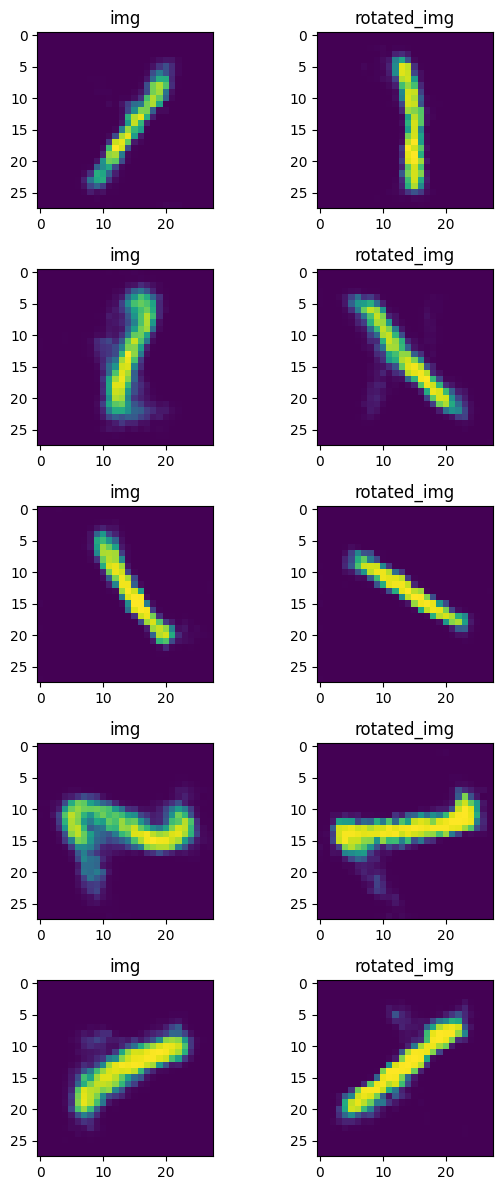

In [11]:
logvar = torch.zeros_like(train_data[0][0])
std = torch.exp(0.5 * logvar)
std = std.to(device)

fig, axes = plt.subplots(5, 2, figsize=(6, 12))

i = 0
vae.eval()
with torch.no_grad():
    for latent, rotated_latent in train_data:
        latent = latent.to(device)
        rotated_latent = rotated_latent.to(device)

        eps = torch.randn_like(std)
        z1 = latent + eps * std
        z2 = rotated_latent + eps * std

        img = vae.decoder(z1.unsqueeze(0))
        rotated_img = vae.decoder(z2.unsqueeze(0))

        axes[i, 0].imshow(img.squeeze(0).squeeze(0).cpu())
        axes[i, 0].set_title("img")
        axes[i, 1].imshow(rotated_img.squeeze(0).squeeze(0).cpu())
        axes[i, 1].set_title("rotated_img")

        i += 1
        if (i == 5):
            break

plt.tight_layout()
plt.show()

In [12]:
class MLP(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.mlp_layers = nn.Sequential(
            nn.Linear(latent_dim, 128),    # (1, 64) -> (1, 128)
            nn.ReLU(),

            nn.Linear(128, 128),    # (1, 128) -> (1, 128)
            nn.ReLU(),
            
            nn.Linear(128, latent_dim),    # (1, 128) -> (1, 64)
        )
    
    def forward(self, x):
        z = self.mlp_layers(x)
        
        return z

In [13]:
def train_one_epoch(model, train_dataloader, test_dataloader, loss_func, optimizer, device):
    train_loss = 0

    model.train()
    for latent, rotated_latent in tqdm(train_dataloader, desc="Training"):
        latent = latent.to(device)
        rotated_latent = rotated_latent.to(device)

        latent_out = model(latent)

        optimizer.zero_grad()
        loss = loss_func(latent_out, rotated_latent)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    
    test_loss = 0

    model.eval()
    with torch.no_grad():
        for latent, rotated_latent in tqdm(test_dataloader, desc="Validating"):
            latent = latent.to(device)
            rotated_latent = rotated_latent.to(device)

            latent_out = model(latent)
            loss = loss_func(latent_out, rotated_latent)

            test_loss += loss.item()
    
    train_loss /= len(train_dataloader)   
    test_loss /= len(test_dataloader)  

    return train_loss, test_loss

In [14]:
def visualize(model, vae, test_dataloader, epoch, device):
    sample_in = []
    sample_out = []
    sample_true = []

    model.eval()
    batch = 0
    with torch.no_grad():
        for latent, rotated_latent in test_dataloader:
            latent = latent.to(device)
            rotated_latent = rotated_latent.to(device)

            latent_out = model(latent)

            sample_in.append(vae.decoder(latent))
            sample_out.append(vae.decoder(latent_out))
            sample_true.append(vae.decoder(rotated_latent))

            break
    
    sample_in = torch.cat(sample_in, dim=0)
    sample_out = torch.cat(sample_out, dim=0)
    sample_true = torch.cat(sample_true, dim=0)

    fig, axes = plt.subplots(5, 3, figsize=(6, 12))
    for i in range(5):
        axes[i, 0].imshow(sample_in[i].squeeze(0).cpu())
        axes[i, 0].set_title("input")
        axes[i, 1].imshow(sample_out[i].squeeze(0).cpu())
        axes[i, 1].set_title("output")
        axes[i, 2].imshow(sample_true[i].squeeze(0).cpu())
        axes[i, 2].set_title("true label")
    
    plt.tight_layout()
    plt.savefig(f"task2_results/mlp_output_epoch_{epoch}.png")
    plt.close()


In [15]:
def train(num_epochs, model, vae, train_dataloader, test_dataloader, loss_func, optimizer, device, patience):
    train_losses = []
    test_losses = []

    best_test_loss = float("inf")
    patience_count = 0
    for epoch in range(num_epochs):
        train_loss, test_loss = train_one_epoch(model, train_dataloader, test_dataloader, loss_func, optimizer, device)

        train_losses.append(train_loss)
        test_losses.append(test_loss)

        visualize(model, vae, test_dataloader, epoch, device)

        print(f"Epoch {epoch} | train_loss: {train_loss:.4f} | test_loss: {test_loss:.4f}")

        if (test_loss < best_test_loss):
            patience_count = 0
            best_test_loss = test_loss
            torch.save(model.state_dict(), "task2_results/best_model.pt")
        else:
            patience_count += 1
            if (patience_count >= patience):
                print("Early stopping")
                break

    return train_losses, test_losses

In [17]:
latent_dim = 64
mlp = MLP(latent_dim)
mlp = mlp.to(device)

summary(mlp, (16, 1, 64))

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [16, 1, 64]               --
├─Sequential: 1-1                        [16, 1, 64]               --
│    └─Linear: 2-1                       [16, 1, 128]              8,320
│    └─ReLU: 2-2                         [16, 1, 128]              --
│    └─Linear: 2-3                       [16, 1, 128]              16,512
│    └─ReLU: 2-4                         [16, 1, 128]              --
│    └─Linear: 2-5                       [16, 1, 64]               8,256
Total params: 33,088
Trainable params: 33,088
Non-trainable params: 0
Total mult-adds (M): 0.53
Input size (MB): 0.00
Forward/backward pass size (MB): 0.04
Params size (MB): 0.13
Estimated Total Size (MB): 0.18

In [18]:
os.makedirs("task2_results", exist_ok=True)
num_epochs = 50
beta = 1
lr = 1e-4
patience = 5
loss_func = nn.MSELoss(reduction="mean")
optimizer = torch.optim.Adam(mlp.parameters(), lr=lr)

train_losses, test_losses = train(num_epochs, mlp, vae, train_dataloader, test_dataloader, loss_func, optimizer, device, patience)

Validating: 100%|██████████| 407/407 [00:00<00:00, 511.48it/s]


Epoch 0 | train_loss: 0.0294 | test_loss: 0.0070


Validating: 100%|██████████| 407/407 [00:00<00:00, 561.30it/s]


Epoch 1 | train_loss: 0.0060 | test_loss: 0.0053


Validating: 100%|██████████| 407/407 [00:00<00:00, 480.67it/s]


...

Epoch 47 | train_loss: 0.0032 | test_loss: 0.0032


Validating: 100%|██████████| 407/407 [00:00<00:00, 457.91it/s]


Epoch 48 | train_loss: 0.0032 | test_loss: 0.0032


Validating: 100%|██████████| 407/407 [00:00<00:00, 437.32it/s]


Epoch 49 | train_loss: 0.0032 | test_loss: 0.0032


In [19]:
plt.figure()
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("task2_results/total_loss.png")
plt.close()